In [1]:
import richfile as rfs
import numpy as np
import pandas as pd
from scipy import sparse
# register numpy, pandas and scipy types to richfile
if not ("pandas_dataframe" in [prop["type_name"] for prop in rfs.functions._TYPE_LOOKUP]):
    rfs.functions.register_type(
        type_name="pandas_dataframe",
        function_load=lambda path: pd.read_csv(path),
        function_save=lambda path, obj: obj.to_csv(path),
        object_class=pd.DataFrame,
        library="pandas",
        suffix="csv",
    )
if not ("pandas_series" in [prop["type_name"] for prop in rfs.functions._TYPE_LOOKUP]):    
    rfs.functions.register_type(
        type_name="pandas_series",
        function_load=lambda path: pd.read_csv(path, squeeze=True),
        function_save=lambda path, obj: obj.to_csv(path),
        object_class=pd.Series,
        library="pandas",
        suffix="csv",
)
if not ("scipy_sparse" in [prop["type_name"] for prop in rfs.functions._TYPE_LOOKUP]):
    rfs.functions.register_type(
        type_name="scipy_sparse",
        function_load=lambda path: sparse.load_npz(path),
        function_save=lambda path, obj: sparse.save_npz(path, obj),
        object_class=sparse.csr_matrix,
        library="scipy",
        suffix="npz",
)
if not ("numpy_array" in [prop["type_name"] for prop in rfs.functions._TYPE_LOOKUP]):
    rfs.functions.register_type(
        type_name="numpy_array",
        function_load=lambda path: np.load(path, allow_pickle=True),
        function_save=lambda path, obj: np.save(path, obj),
        object_class=np.ndarray,
        library="numpy",
        suffix="npy",
    )
if "scipy_sparse_array" not in [x["type_name"] for x in rfs.functions._TYPE_LOOKUP]:
    rfs.functions.register_type(
        type_name="scipy_sparse_array",
        function_load=lambda path: sparse.load_npz(path).toarray(),
        function_save=lambda path, obj: sparse.save_npz(path, sparse.csr_matrix(obj)),
        object_class=np.ndarray,
        library="scipy",
        suffix="npz",
    )

In [2]:
import os
sampling_rate = 30  # Hz
data_root = r'C:\Data\datasets\bmi_packets\bmi_packets'
file_name_list = os.listdir(data_root)
# filter the names that have the .richfile extension
file_name_list = [name for name in file_name_list if name.endswith(".richfile")]
output_root = r'C:\Users\alireza\Documents\Git\BCI_analysis\output'


In [3]:
file_name_list

['mouse_0322R.richfile',
 'mouse_0403L.richfile',
 'mouse_0403R.richfile',
 'mouse_0916N.richfile']

In [4]:
#day_list

In [5]:
# let read experiment traking data for each day and stored in the xlsx file (with diffrent tad, one for each animal)
experiment_log_path = os.path.join(data_root, "RH + GH experiment log.xlsx")

# read the excel file and get the sheet names
xls = pd.ExcelFile(experiment_log_path)
sheet_names = xls.sheet_names

# read each sheet into a dictionary
experiment_tracking = {
    sheet_name: pd.read_excel(experiment_log_path, sheet_name=sheet_name)
    for sheet_name in sheet_names
}

# optional: remove fully empty rows/columns from each sheet
experiment_tracking = {
    sheet_name: df.dropna(how="all").dropna(axis=1, how="all")
    for sheet_name, df in experiment_tracking.items()
}

# display sheet names and preview
print(sheet_names)


['mouse_0921R', 'mouse_0921L', 'mouse_0914', 'mouse_0908', 'mouse_0916N', 'mouse_0403L', 'mouse_0403R', 'mouse_0322N', 'mouse_0322R', 'mouse_0315N', 'mouse_0315L']


In [6]:

#fi = 1
#file_name = file_name_list[fi]
#mouse_name = os.path.splitext(file_name)[0]
mouse_name = "mouse_0403L"
file_name = f"{mouse_name}.richfile"
output_dir = os.path.join(output_root, mouse_name)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

r = rfs.RichFile(os.path.join(data_root, file_name))
day_list = r["data_neural_aligned"].keys()
day_zero = r["date_day0"].load()
# adjusting day zero if it needed
#day_zero = '20230703'
# valid_days are the days that  after or same as the day_zero
day_zero_idx = day_list.index(day_zero)


# let get have some mesure of behvior
all_reward_rate = np.zeros(len(day_list))
active_reward_rate = np.zeros(len(day_list))
reward_prograce_rate_list = []
active_reward_times_min_list = []
exp_length_min_list = []
sliding_bin_size_min = 2.5
sliding_bin_size_sec = sliding_bin_size_min * 60
for day_idx in range(len(day_list)):
    day_name = day_list[day_idx]
    all_reward_times_signal = r["data_ws"][day_name]["rewards"].load()
    reward_times_typed = r["reward_times_typed"][day_name].load()
    
    # detect all the threshold crossings in the reward signal  
    threshold = 0.5 * np.nanmax(all_reward_times_signal)
    all_reward_times = np.where(all_reward_times_signal > threshold)[0]
    # let remove the consecutive samples that are above the threshold, and keep only the first sample of each crossing
    all_reward_times = all_reward_times[np.insert(np.diff(all_reward_times) > 1, 0, True)]
    all_reward_times_sec = all_reward_times / sampling_rate
    exp_length_min = len(all_reward_times_signal) / (sampling_rate* 60)

    active_reward_times = reward_times_typed[(1, 1, 1, 1)]
    active_reward_times_sec = active_reward_times / sampling_rate
    active_reward_times_min_list.append(active_reward_times_sec / 60)

    active_reward_rate[day_idx] = len(active_reward_times) / exp_length_min
    all_reward_rate[day_idx] = len(all_reward_times) / exp_length_min
    
    # let have active reward rate in sliding bins 
    active_reward_rate_in_each_bin = np.zeros(int(exp_length_min * 60-sliding_bin_size_sec+1))
    for bin_idx in range(len(active_reward_rate_in_each_bin)):
        bin_start_time = bin_idx-sliding_bin_size_sec/2
        bin_end_time = bin_idx+sliding_bin_size_sec/2
        active_reward_rate_in_each_bin[bin_idx] = np.sum((active_reward_times_sec >= bin_start_time) & (active_reward_times_sec < bin_end_time)) / sliding_bin_size_sec
    reward_prograce_rate_list.append(active_reward_rate_in_each_bin)
    exp_length_min_list.append(exp_length_min)
    


c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type numpy_array.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


In [7]:
exp_meta = experiment_tracking[mouse_name]

columns_new_name = ['date', 'laser_power', 'obj', 'goniometer_x_set',
                    'goniometer_y_set', 'goniometer_x_mesured', 'goniometer_y_mesured', 
                    'mouse_orginal_weight', 'mouse_weight_per_day', 'mouse_weight_persantage',
                    'meanlm intensity', 'num_of_rewards', 'Decoder factor', 'Trial type',
                    'block type', 'rig temperature', 'note', 'Laser power percent used', 
                    'incl. sensor mode']

exp_meta.columns = columns_new_name
#exp_meta.head()
# Date in  this sf is like ' 2023-07-02 00:00:00' but in other places is in this format 20230703 let add a column at
# the first of the dataframe with the date in the same format as in the day_list (20230703), 
# the row of this df is not matching with the day_list, so we need covert the date from the 'date' 
# column ( 2023-07-02 00:00:00) to the same format as in the day_list (20230703) 
import datetime
data_column = exp_meta['date']
data_converted_column = [
    x.strftime("%Y%m%d") if isinstance(x, (datetime.datetime, pd.Timestamp)) else None
    for x in data_column]
exp_meta['date_converted'] = data_converted_column
# bring the new column to the first position
exp_meta = exp_meta[['date_converted'] + [col for col in exp_meta.columns if col != 'date_converted']]
#exp_meta.head()
mouse_weight_persantage = np.zeros(len(day_list))
for day_idx in range(len(day_list)):
    day_name = day_list[day_idx]
    date_converted = exp_meta.loc[exp_meta['date_converted'] == day_name, 'date_converted'].values
    if len(date_converted) > 0:
        mouse_weight_persantage[day_idx] = exp_meta.loc[exp_meta['date_converted'] == day_name, 'mouse_weight_persantage'].values[0]
    else:
        mouse_weight_persantage[day_idx] = np.nan


In [8]:
# here we will find extract some trial information that
num_of_hits = np.zeros(len(day_list))
num_of_misses = np.zeros(len(day_list))
hit_rate = np.zeros(len(day_list))
remapping_or_not = np.zeros(len(day_list))
remapping_start_frame = np.zeros(len(day_list))
trials_outcome_list = []
hit_tirals_list = []
miss_tirals_list = []
tirals_lengthInFrame_list = []
trials_start_frams_list = []
trails_factor_used_list = []
trials_end_frams_list = []
frame_of_remaping_start = np.zeros(len(day_list))
for day_idx in range(len(day_list)):
    day_name = day_list[day_idx]
    trials_df = r["extras"]["logger_dfs"][day_name]['trials'].load()
    true_tirals = (trials_df['trialType_feedbackLinked'] == 1) &(
                trials_df['trialType_cursorOn'] == 1) &(
                trials_df['trialType_rewardOn'] == 1)
    #factor_to_use = r["extras"]["expParams"][day_name]["baselineStuff"]["factor_to_use"].load()
    #len(np.where(trials_df['factor_to_use'] != factor_to_use)[0])

    if np.sum(true_tirals)>0:
        # do something
        num_of_hits[day_idx] = trials_df['success_outcome'][true_tirals].sum()
        hit_tirals_list.append(np.where(trials_df['success_outcome'][true_tirals] == 1)[0])
        num_of_misses[day_idx] = len(np.where(trials_df['success_outcome'][true_tirals] == 0)[0])
        miss_tirals_list.append(np.where(trials_df['success_outcome'][true_tirals] == 0)[0])
        hit_rate[day_idx] = num_of_hits[day_idx] / (num_of_hits[day_idx] + num_of_misses[day_idx]) if (num_of_hits[day_idx] + num_of_misses[day_idx]) > 0 else np.nan
        trials_outcome_list.append(trials_df['success_outcome'][true_tirals].values)
        tirals_lengthInFrame_list.append(trials_df['frameNum_trialEnd'][true_tirals].values - trials_df['frameNum_trialStart'][true_tirals].values)
        trials_start_frams = trials_df['frameNum_trialStart'][true_tirals].values
        trails_end_frams = trials_df['frameNum_trialEnd'][true_tirals].values
        trials_start_frams_list.append(trials_start_frams)
        trials_end_frams_list.append(trails_end_frams)
        trails_factors = trials_df['factor_to_use'][true_tirals].values
        trails_factor_used_list.append(trails_factors)
        # if there is more than one factor_to_use in the day then it is the remapping day, and we will find the frame of the remapping start
        if len(np.unique(trails_factors)) > 1:
            remapping_or_not[day_idx] = True
            base_factor = trails_factors[0]
            first_trial_with_new_factor_idx = np.where(trails_factors != base_factor)[0][0]-1 # this -1 is very important because the first trial with new factor is start right after the last trial with the old factor
            remapping_start_frame[day_idx] = trails_end_frams[first_trial_with_new_factor_idx]
        else:
            remapping_or_not[day_idx] = False
            remapping_start_frame[day_idx] = np.nan
    else:
        num_of_hits[day_idx] = np.nan
        num_of_misses[day_idx] = np.nan
        hit_tirals_list.append(np.array([]))
        miss_tirals_list.append(np.array([]))
        hit_rate[day_idx] = np.nan
        trials_outcome_list.append(np.array([]))
        tirals_lengthInFrame_list.append(np.array([]))
        trials_start_frams_list.append(np.array([]))
        trials_end_frams_list.append(np.array([]))
        trails_factor_used_list.append(np.array([]))

        
#trials = expLoggers['trials'].load()
#trials    


c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type pandas_dataframe.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


In [9]:
first_remaping_day = day_list[np.where(remapping_or_not)[0][0]] if np.any(remapping_or_not) else None
end_remaping_phase = day_list[np.where(remapping_or_not)[0][-1]] if np.any(remapping_or_not) else None
# valid_days are the days that  after or same as the day_zero
first_remaping_day_idx = day_list.index(first_remaping_day)
end_remaping_phase_idx = day_list.index(end_remaping_phase)
stabel_control_days_idx = list(range(day_zero_idx, first_remaping_day_idx))
remping_days_idx = list(range(first_remaping_day_idx, end_remaping_phase_idx+1))

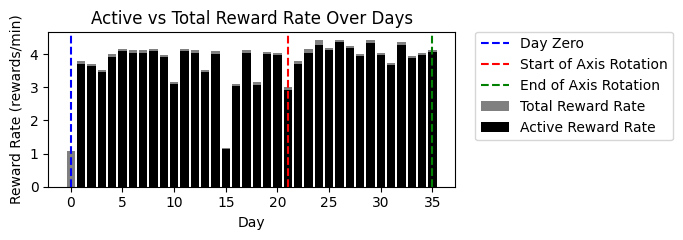

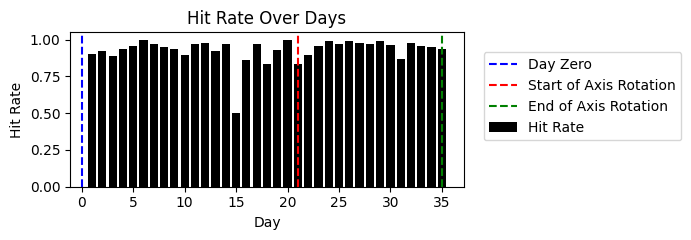

C:\Users\alireza\AppData\Local\Temp\ipykernel_20684\3227333943.py:40: RuntimeWarning: Mean of empty slice
  avrage_trial_length_sec = [np.nanmean(tirals_lengthInFrame_list[day_idx][trials_outcome_list[day_idx]==1]) / sampling_rate for day_idx in range(len(day_list))]
c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


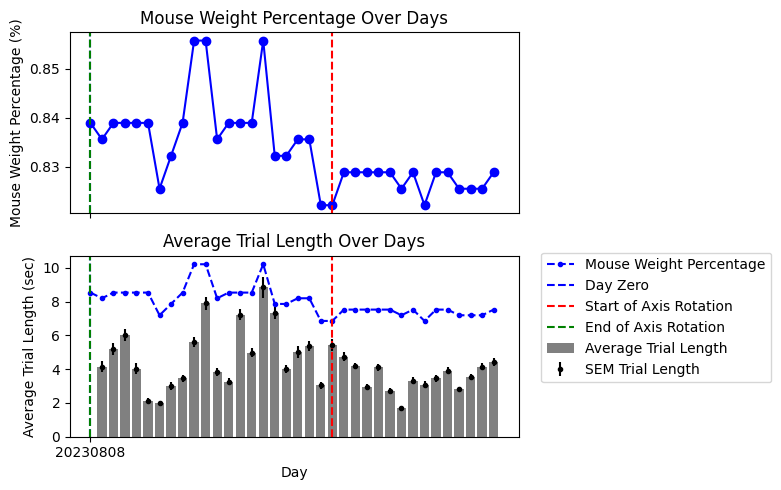

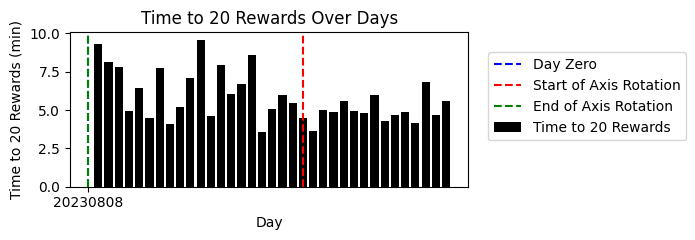

In [10]:
# let makle a Stacked Bar plot of the reward rates gay is the active reward rate and blue is the total reward rate 
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 2.5))
plt.bar(range(len(all_reward_rate)), all_reward_rate, label="Total Reward Rate", color='gray')
plt.bar(range(len(active_reward_rate)), active_reward_rate, label="Active Reward Rate", color='black')
# let have vertical lines to show the start and end of the axis rotation period
plt.axvline(x=day_zero_idx, color='b', linestyle='--', label='Day Zero')
if first_remaping_day_idx is not None:
    plt.axvline(x=first_remaping_day_idx, color='r', linestyle='--', label='Start of Axis Rotation')
    plt.axvline(x=end_remaping_phase_idx, color='g', linestyle='--', label='End of Axis Rotation')
plt.xlabel("Day")
plt.ylabel("Reward Rate (rewards/min)")
plt.title("Active vs Total Reward Rate Over Days")
plt.legend(loc= [1.05, .3])
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_rate_over_days.png")
plt.savefig(output_path, dpi=300)
plt.show()

# let plit the hit rate over days
plt.figure(figsize=(7, 2.5))
plt.bar(range(len(hit_rate)), hit_rate, label="Hit Rate", color='black')
# let have vertical lines to show the start and end of the axis rotation period
plt.axvline(x=day_zero_idx, color='b', linestyle='--', label='Day Zero')
if first_remaping_day_idx is not None:
    plt.axvline(x=first_remaping_day_idx, color='r', linestyle='--', label='Start of Axis Rotation')
    plt.axvline(x=end_remaping_phase_idx, color='g', linestyle='--', label='End of Axis Rotation')
plt.xlabel("Day")
plt.ylabel("Hit Rate")
plt.title("Hit Rate Over Days")
plt.legend(loc= [1.05, .3])
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_hit_rate_over_days.png")
plt.savefig(output_path, dpi=300)
plt.show()

# plot the average trial length over days, with error bars showing the standard error of the mean
# in a 2 subplot that the top is the the plot of the waight percentage over days and the bottom is the average trial length over days(share the x axis)
# let plot the weight percentage over days
avrage_trial_length_sec = [np.nanmean(tirals_lengthInFrame_list[day_idx][trials_outcome_list[day_idx]==1]) / sampling_rate for day_idx in range(len(day_list))]
sem_trial_length_sec = [np.nanstd(tirals_lengthInFrame_list[day_idx][trials_outcome_list[day_idx]==1]) / (sampling_rate * np.sqrt(len(tirals_lengthInFrame_list[day_idx][trials_outcome_list[day_idx]==1]))) for day_idx in range(len(day_list))]
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(range(len(mouse_weight_persantage)), mouse_weight_persantage, label='', color='blue', marker='o')
ax[0].set_ylabel("Mouse Weight Percentage (%)")
ax[0].set_title("Mouse Weight Percentage Over Days")
ax[1].bar(range(len(avrage_trial_length_sec)), avrage_trial_length_sec, label="Average Trial Length", color='gray')
ax[1].errorbar(range(len(avrage_trial_length_sec)), avrage_trial_length_sec, yerr=sem_trial_length_sec, fmt='.', color='black', label="SEM Trial Length")  
ax[1].plot(range(len(mouse_weight_persantage)), (mouse_weight_persantage-np.mean(mouse_weight_persantage))*100+ 8,
            label="Mouse Weight Percentage", color='blue', marker='.', linestyle='--')
ax[1].set_xlabel("Day")
ax[1].set_ylabel("Average Trial Length (sec)")
ax[1].set_title("Average Trial Length Over Days")
# let have vertical lines to show the start and end of the axis rotation period
for a in ax:
    a.axvline(x=day_zero_idx, color='b', linestyle='--', label='Day Zero')
    a.axvline(x=first_remaping_day_idx, color='r', linestyle='--', label='Start of Axis Rotation')
    a.axvline(x=end_remaping_phase, color='g', linestyle='--', label='End of Axis Rotation')
ax[1].legend(loc= [1.05, .3])
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_weight_and_trial_length_over_days.png")
plt.savefig(output_path, dpi=300)
plt.show()

# let plot the time it need to rich 30 rewards in each day
plt.figure(figsize=(7, 2.5))
k_rewards = 20
time_to_k_rewards_min = [active_reward_times_min_list[day_idx][k_rewards-1] if len(active_reward_times_min_list[day_idx]) >= k_rewards else np.nan for day_idx in range(len(day_list))]
plt.bar(range(len(time_to_k_rewards_min)), time_to_k_rewards_min, label=f"Time to {k_rewards} Rewards", color='black')
# let have vertical lines to show the start and end of the axis rotation period
plt.axvline(x=day_zero_idx, color='b', linestyle='--', label='Day Zero')
plt.axvline(x=first_remaping_day_idx, color='r', linestyle='--', label='Start of Axis Rotation')
plt.axvline(x=end_remaping_phase, color='g', linestyle='--', label='End of Axis Rotation')
plt.xlabel("Day")
plt.ylabel(f"Time to {k_rewards} Rewards (min)")
plt.title(f"Time to {k_rewards} Rewards Over Days")
plt.legend(loc= [1.05, .3])
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_time_to_{k_rewards}_rewards_over_days.png")
plt.savefig(output_path, dpi=300)
plt.show()  

In [11]:
import seaborn as sns
smoothing_window_size = 20
reward_arrays = [np.asarray(x, dtype=float).ravel() for x in reward_prograce_rate_list]
max_len = max(len(x) for x in reward_arrays)
all_smoothed_reward_rate_stacked = np.full(
    (len(reward_arrays), max_len),
    np.nan,
    dtype=float,
)
for i, x in enumerate(reward_arrays):
    smoothed_reward_rate = np.convolve(x, np.ones(smoothing_window_size)/smoothing_window_size, mode='same')
    all_smoothed_reward_rate_stacked[i, :len(x)] = smoothed_reward_rate

In [12]:
def shift_with_nan(x, shift_bins):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)

    if shift_bins > 0:
        y[shift_bins:] = x[:-shift_bins]
    elif shift_bins < 0:
        y[:shift_bins] = x[-shift_bins:]
    else:
        y[:] = x

    return y

C:\Users\alireza\AppData\Local\Temp\ipykernel_20684\3421238675.py:5: RuntimeWarning: Mean of empty slice
  average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked[stabel_control_days_idx], axis=0)
C:\Users\alireza\AppData\Local\Temp\ipykernel_20684\3421238675.py:35: RuntimeWarning: Mean of empty slice
  average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked_aligned[remping_days_idx], axis=0)


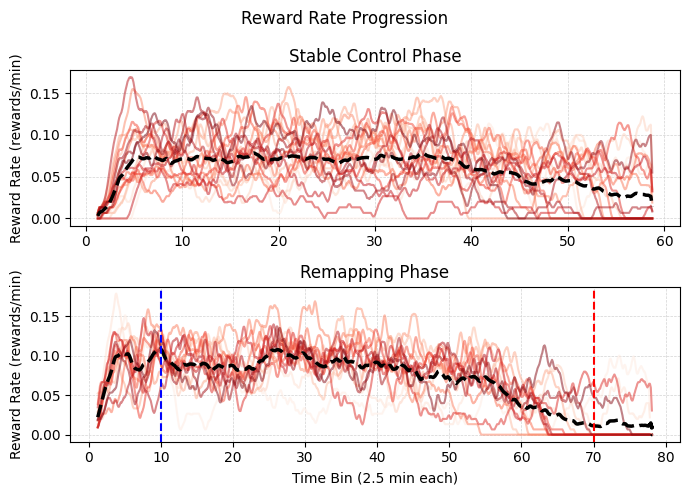

In [13]:
# plot the reward rate progress over time for each day let give a color shade to each day

smoothing_window_size = 20
fig, ax = plt.subplots(2, 1, figsize=(7, 5))    
average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked[stabel_control_days_idx], axis=0)
color_palette = sns.color_palette("Reds", len(stabel_control_days_idx))
bins_time_min = (np.arange(all_smoothed_reward_rate_stacked.shape[1]) / 60) + sliding_bin_size_min/2
for day_idx in stabel_control_days_idx:
    start_from_day_zero = day_idx - day_zero_idx
    ax[0].plot(bins_time_min, all_smoothed_reward_rate_stacked[day_idx], label=f"Day {start_from_day_zero}",
               alpha=0.5, linewidth=1.5, color=color_palette[start_from_day_zero])
ax[0].plot(bins_time_min, average_reward_rate, label="Average", color="black", linewidth=2.5, linestyle="--")
ax[0].set_ylabel("Reward Rate (rewards/min)")
ax[0].set_title("Stable Control Phase")
ax[0].grid(color='lightgray', linestyle='--', linewidth=0.5)   

if first_remaping_day_idx is not None and end_remaping_phase_idx is not None:
    rotaion_to_new_time = 10
    rotion_to_old_time = 60+10
    # first we need to make new all_smoothed_reward_rate_stacked that all the start of the remapping phase is aligned to the same time point in the x axis, 
    # so we will shift the reward rate for each day by the difference between the remapping start time and nomianl rotaion_to_new_time
    all_smoothed_reward_rate_stacked_aligned = np.full_like(
        all_smoothed_reward_rate_stacked,
        np.nan,
        dtype=float,
        )
    for day_idx in remping_days_idx:
        remapping_start_min_day = remapping_start_frame[day_idx] / sampling_rate / 60
        shift_min = rotaion_to_new_time - remapping_start_min_day
        shift_bins = int(round(shift_min * 60))  # correct if bins are 1 second wide
        all_smoothed_reward_rate_stacked_aligned[day_idx] = shift_with_nan(
            all_smoothed_reward_rate_stacked[day_idx],
            shift_bins,
        )   
    average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked_aligned[remping_days_idx], axis=0)
    color_palette = sns.color_palette("Reds", len(remping_days_idx))
    for day_idx in remping_days_idx:
        day_from_start_of_axis_rotaion = day_idx - first_remaping_day_idx
        remapping_start_min_day = remapping_start_frame[day_idx]/sampling_rate/60
        # we want aligend eveything so the remapping start time is at the same time point in the x axis, so we will shift 
        # the reward rate for each day by the difference between the remapping start time and the average remapping start time across all days
        ax[1].plot(bins_time_min, all_smoothed_reward_rate_stacked_aligned[day_idx], label=f"Day {day_from_start_of_axis_rotaion}",
                    alpha=0.5, linewidth=1.5, color=color_palette[day_from_start_of_axis_rotaion])
    ax[1].plot(bins_time_min, average_reward_rate, label="Average", color="black",  linewidth=2.5, linestyle="--")
    ax[1].axvline(x=rotaion_to_new_time, color='b', linestyle='--', label='Rotation to New')
    ax[1].axvline(x=rotion_to_old_time, color='r', linestyle='--', label='Rotation to Old')
    ax[1].set_xlabel(f"Time Bin ({sliding_bin_size_min} min each)")
    ax[1].set_ylabel("Reward Rate (rewards/min)")
    ax[1].set_title("Remapping Phase")
    ax[1].grid(color='lightgray', linestyle='--', linewidth=0.5)  
plt.suptitle(f"Reward Rate Progression")
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_rate_progression.png")
plt.savefig(output_path, dpi=300)
plt.show()

C:\Users\alireza\AppData\Local\Temp\ipykernel_20684\4081114686.py:3: RuntimeWarning: Mean of empty slice
  average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked[stabel_control_days_idx[:FIRST_K_DAYS]], axis=0)
C:\Users\alireza\AppData\Local\Temp\ipykernel_20684\4081114686.py:29: RuntimeWarning: Mean of empty slice
  average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked_aligned[remping_days_idx[:FIRST_K_DAYS]], axis=0)


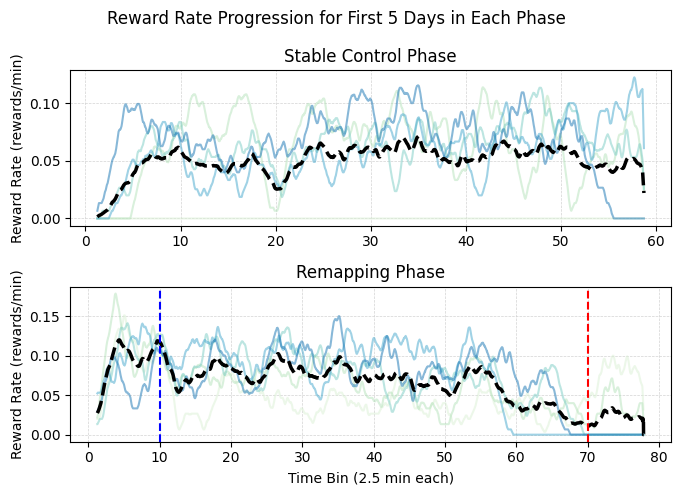

In [14]:
FIRST_K_DAYS = 5
fig, ax = plt.subplots(2, 1, figsize=(7, 5))    
average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked[stabel_control_days_idx[:FIRST_K_DAYS]], axis=0)
color_palette = sns.color_palette("GnBu", FIRST_K_DAYS)
for day_idx in stabel_control_days_idx[:FIRST_K_DAYS]:
    start_from_day_zero = day_idx - day_zero_idx
    ax[0].plot(bins_time_min, all_smoothed_reward_rate_stacked[day_idx], label=f"Day {start_from_day_zero}",
               alpha=0.5, linewidth=1.5, color=color_palette[start_from_day_zero])
ax[0].plot(bins_time_min, average_reward_rate, label="Average", color="black", linewidth=2.5, linestyle="--")
ax[0].set_ylabel("Reward Rate (rewards/min)")
ax[0].set_title("Stable Control Phase")
ax[0].grid(color='lightgray', linestyle='--', linewidth=0.5)    
if first_remaping_day_idx is not None and end_remaping_phase_idx is not None:
    rotaion_to_new_time = 10
    rotion_to_old_time = 60+10
    all_smoothed_reward_rate_stacked_aligned = np.full_like(
        all_smoothed_reward_rate_stacked,
        np.nan,
        dtype=float,
        )
    for day_idx in remping_days_idx:
        remapping_start_min_day = remapping_start_frame[day_idx] / sampling_rate / 60
        shift_min = rotaion_to_new_time - remapping_start_min_day
        shift_bins = int(round(shift_min * 60))  # correct if bins are 1 second wide
        all_smoothed_reward_rate_stacked_aligned[day_idx] = shift_with_nan(
            all_smoothed_reward_rate_stacked[day_idx],
            shift_bins,
        ) 
    average_reward_rate = np.nanmean(all_smoothed_reward_rate_stacked_aligned[remping_days_idx[:FIRST_K_DAYS]], axis=0)
    color_palette = sns.color_palette("GnBu", FIRST_K_DAYS)
    for day_idx in remping_days_idx[:FIRST_K_DAYS]:
        day_from_start_of_axis_rotaion = day_idx - first_remaping_day_idx
        remapping_start_min_day = remapping_start_frame[day_idx]/sampling_rate/60
        # we want aligend eveything so the remapping start time is at the same
        # time point in the x axis, so we will shift the reward rate for each day by the difference between the remapping start time and the average remapping start time across all days
        shift = rotaion_to_new_time - remapping_start_min_day
        ax[1].plot(bins_time_min, all_smoothed_reward_rate_stacked_aligned[day_idx], label=f"Day {day_from_start_of_axis_rotaion}",
                    alpha=0.5, linewidth=1.5, color=color_palette[day_from_start_of_axis_rotaion])
    ax[1].plot(bins_time_min, average_reward_rate, label="Average", color="black", linewidth=2.5, linestyle="--")
    ax[1].axvline(x=rotaion_to_new_time, color='b', linestyle='--', label='Rotation to New')
    ax[1].axvline(x=rotion_to_old_time, color='r', linestyle='--', label='Rotation to Old')
    ax[1].set_xlabel(f"Time Bin ({sliding_bin_size_min} min each)")
    ax[1].set_ylabel("Reward Rate (rewards/min)")
    ax[1].set_title("Remapping Phase")
    ax[1].grid(color='lightgray', linestyle='--', linewidth=0.5)  
plt.suptitle(f"Reward Rate Progression for First {FIRST_K_DAYS} Days in Each Phase")
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_rate_progression_first_{FIRST_K_DAYS}_days.png")
plt.savefig(output_path, dpi=300)
plt.show()

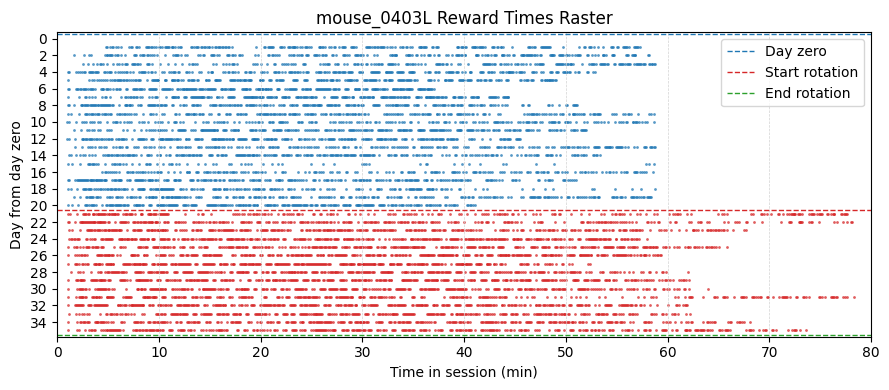

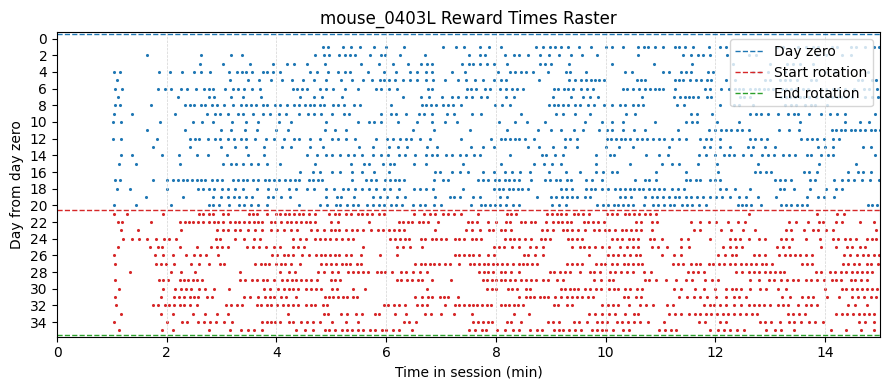

In [29]:
# let make the reward times raster, each row is a day and each dot is a reward time, the x axis is time in minutes

row_colors = []
for day_idx in range(len(day_list)):
    if day_idx in stabel_control_days_idx:
        row_colors.append("tab:blue")
    elif day_idx in remping_days_idx:
        row_colors.append("tab:red")
    else:
        row_colors.append("0.45")

fig_height = max(4, 0.1 * len(day_list))


fig, ax = plt.subplots(figsize=(9, fig_height))
for day_idx, reward_times_min in enumerate(active_reward_times_min_list):
    y = np.full_like(reward_times_min, day_idx, dtype=float)
    ax.scatter(
        reward_times_min,
        y,
        s=4,
        color=row_colors[day_idx],
        alpha=0.75,
        linewidths=0,
    )
ax.axhline(day_zero_idx - 0.5, color="tab:blue", linestyle="--", linewidth=1, label="Day zero")
ax.axhline(first_remaping_day_idx - 0.5, color="tab:red", linestyle="--", linewidth=1, label="Start rotation")
ax.axhline(end_remaping_phase_idx + 0.5, color="tab:green", linestyle="--", linewidth=1, label="End rotation")
tick_step = 2
yticks = np.arange(0, len(day_list), tick_step)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{i - day_zero_idx:d}" for i in yticks])
ax.set_ylim(-0.75, len(day_list) - 0.25)
ax.set_xlim(0, np.nanmax(exp_length_min_list))
ax.invert_yaxis()
ax.set_xlabel("Time in session (min)")
ax.set_ylabel("Day from day zero")
ax.set_title(f"{mouse_name} Reward Times Raster")
ax.grid(axis="x", color="lightgray", linestyle="--", linewidth=0.5)
ax.legend(loc="upper right")
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_times_raster.png")
plt.savefig(output_path, dpi=300)
plt.show()

# let do it only for the first 15 minutes of each session,
fig, ax = plt.subplots(figsize=(9, fig_height))
for day_idx, reward_times_min in enumerate(active_reward_times_min_list):
    reward_times_min = reward_times_min[reward_times_min <= 15]
    y = np.full_like(reward_times_min, day_idx, dtype=float)
    ax.scatter(
        reward_times_min,
        y,
        s=5,
        color=row_colors[day_idx],
        alpha=1,
        linewidths=0,
    )
ax.axhline(day_zero_idx - 0.5, color="tab:blue", linestyle="--", linewidth=1, label="Day zero")
ax.axhline(first_remaping_day_idx - 0.5, color="tab:red", linestyle="--", linewidth=1, label="Start rotation")
ax.axhline(end_remaping_phase_idx + 0.5, color="tab:green", linestyle="--", linewidth=1, label="End rotation")
tick_step = 2
yticks = np.arange(0, len(day_list), tick_step)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{i - day_zero_idx:d}" for i in yticks])
ax.set_ylim(-0.75, len(day_list) - 0.25)
ax.set_xlim(0, 15)
ax.invert_yaxis()
ax.set_xlabel("Time in session (min)")
ax.set_ylabel("Day from day zero")
ax.set_title(f"{mouse_name} Reward Times Raster")
ax.grid(axis="x", color="lightgray", linestyle="--", linewidth=0.5)
ax.legend(loc="upper right")
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_times_raster_first_15_min.png")
plt.savefig(output_path, dpi=300)
plt.show()



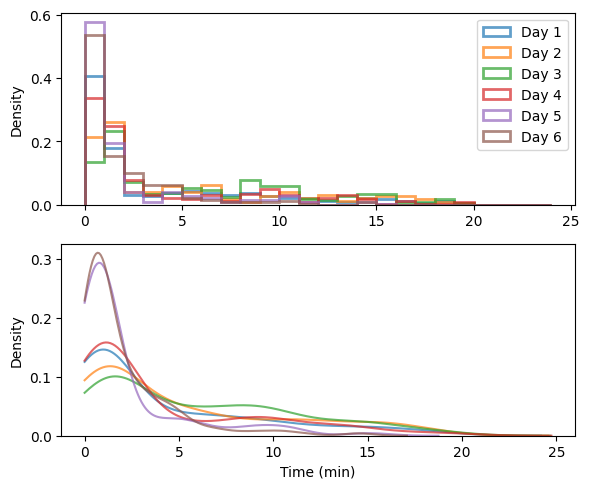

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


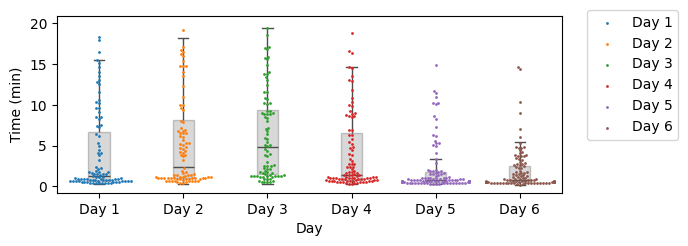

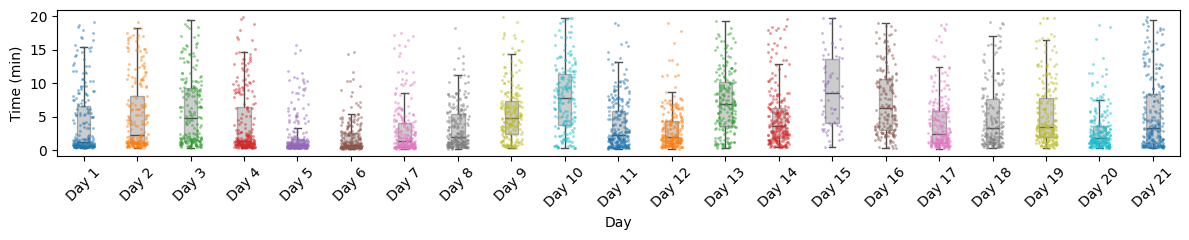

In [30]:
# let plot distribuation of the reward during the first 5 days overlaped
import seaborn as sns
n_first_days = 6
fig, ax = plt.subplots(2,1, figsize=(6, 5))
for day_diff_idx in range(n_first_days):
    day_idx = day_zero_idx + day_diff_idx +1
    day_name = day_list[day_idx]
    trials_outcome = trials_outcome_list[day_idx]
    successful_trials_idx = np.where(trials_outcome == 1)[0]
    active_reward_times_sec = tirals_lengthInFrame_list[day_idx][successful_trials_idx]/sampling_rate
    
    # I jsut want to heep outlines of the histograms, so I will set alpha to 0.5 and density to True
    ax[0].hist(active_reward_times_sec, bins=np.arange(0, 25, 1),
            density=True, label=f"Day {day_diff_idx+1}", histtype='step', linewidth=2, alpha=0.7, color=f"C{day_diff_idx}")
    # let fit a density curve to the histogram using seaborn kdeplot and fix the boundry smoothing (we want to it be bounded in left to zero)
    #  and set the color
    sns.kdeplot(active_reward_times_sec, ax=ax[1], color=f"C{day_diff_idx}",
                 linewidth=1.5, clip_on=False, clip=(0, None), label=None, alpha=0.7)
ax[1].set_xlabel("Time (min)")
ax[0].set_ylabel("Density")
ax[0].legend()
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_times_distribuation_first_{n_first_days}_days.png")
plt.savefig(output_path, dpi=300)
plt.show()

# now let do the vailotion plots of the reward times during the first 5 days 
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 2.5))
for day_diff_idx in range(n_first_days):
    day_idx = day_zero_idx + day_diff_idx +1
    day_name = day_list[day_idx]
    trials_outcome = trials_outcome_list[day_idx]
    successful_trials_idx = np.where(trials_outcome == 1)[0]
    active_reward_times_sec = tirals_lengthInFrame_list[day_idx][successful_trials_idx]/sampling_rate
    
    # let randomly sample 2/3 of the data to make the plot less crowded
    random_sample_idx = np.random.choice(len(active_reward_times_sec), size=int(len(active_reward_times_sec)*4/10), replace=False)
    sns.swarmplot(x=np.full_like(active_reward_times_sec[random_sample_idx], day_diff_idx+1), y=active_reward_times_sec[random_sample_idx],
                  ax=ax, color=f"C{day_diff_idx}", alpha=1, size=2, label=f"Day {day_diff_idx+1}")
    # let add a boxplot on top of the swarmplot
    sns.boxplot(x=np.full_like(active_reward_times_sec, day_diff_idx+1),
                y=active_reward_times_sec, ax=ax, color='gray', fliersize=0, width=0.25, boxprops=dict(alpha=0.3))
    
ax.set_xlabel("Day")
ax.set_ylabel("Time (min)")
ax.set_xticks(range(n_first_days))
ax.set_xticklabels([f"Day {day_diff_idx+1}" for day_diff_idx in range(n_first_days)])
ax.legend(loc=[1.05, .3])
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_times_violin_first_{n_first_days}_days.png")
plt.savefig(output_path, dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(12, 2.5))
for day_diff_idx in range(first_remaping_day_idx - day_zero_idx):
    day_idx = day_zero_idx + day_diff_idx +1
    day_name = day_list[day_idx]
    trials_outcome = trials_outcome_list[day_idx]
    successful_trials_idx = np.where(trials_outcome == 1)[0]
    active_reward_times_sec = tirals_lengthInFrame_list[day_idx][successful_trials_idx]/sampling_rate
    
    # let randomly sample 2/3 of the data to make the plot less crowded
    sns.stripplot(x=np.full_like(active_reward_times_sec, day_diff_idx+1), y=active_reward_times_sec,
                  ax=ax, color=f"C{day_diff_idx}", alpha=.5, size=2, label='', jitter=0.2)
    # let add a boxplot on top of the swarmplot
    sns.boxplot(x=np.full_like(active_reward_times_sec, day_diff_idx+1),
                y=active_reward_times_sec, ax=ax, color='gray', fliersize=0, width=0.25, boxprops=dict(alpha=0.4))
    
ax.set_xlabel("Day")
ax.set_ylabel("Time (min)")
ax.set_xticks(range(first_remaping_day_idx - day_zero_idx))
ax.set_xticklabels([f"Day {day_diff_idx+1}" for day_diff_idx in range(first_remaping_day_idx - day_zero_idx)], rotation=45)
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_reward_times_violin_stable_control_days.png")
plt.savefig(output_path, dpi=300)
plt.show()
   

In [17]:
# get coursor value form the neural data and project it onto the decoder weight vector
def get_coursor_from_neural_data_simple_projection(r, day_name):
    neural_data = r["data_neural_aligned"][day_name].load()
    decoder_ws_mat = r["weights_day0_idxFactors"].load()
    factor_to_use  = r["extras"]["expParams"][day_name]['baselineStuff']['factor_to_use'].load()
    decoder_ws_vec = decoder_ws_mat[:, int(factor_to_use)-1]
    # let find the the neural projection onto the decoder weight vector
    decoder_ws_vec = np.nan_to_num(decoder_ws_vec, nan=0.0)
    neural_projection = (neural_data.T) @ decoder_ws_vec
    return neural_projection


def rolling_zscore_neural_data(neural_data, window_sec=60, sampling_rate=30, min_periods=None, center=False, eps=1e-8):
    """Rolling z-score each neuron over time. Expects neural_data as neurons x time."""
    neural_data = np.asarray(neural_data, dtype=float)
    window_samples = int(round(window_sec * sampling_rate))
    if window_samples < 2:
        raise ValueError("window_sec is too small; rolling window must contain at least 2 samples")
    if min_periods is None:
        min_periods = window_samples

    # pandas rolls down rows, so transpose to time x neurons and transpose back at the end
    neural_df = pd.DataFrame(neural_data.T)
    rolling_mean = neural_df.rolling(window_samples, min_periods=min_periods, center=center).mean().to_numpy().T
    rolling_std = neural_df.rolling(window_samples, min_periods=min_periods, center=center).std(ddof=0).to_numpy().T

    neural_z = (neural_data - rolling_mean) / rolling_std
    neural_z[rolling_std < eps] = 0
    return neural_z


def get_rolling_zscore_neural_data(r, day_name, window_sec=60, min_periods=None, center=False):
    neural_data = r["data_neural_aligned"][day_name].load()
    return rolling_zscore_neural_data(
        neural_data,
        window_sec=window_sec,
        sampling_rate=sampling_rate,
        min_periods=min_periods,
        center=center,
    )


# paper formula:
# c_t = abs(cosine_similarity(w_dec, s_t))**p * ||projection_of_s_t_onto_w_dec||_2
def get_coursor_from_neural_data_decoder_formula(r, day_name, p=2, sampling_rate=30):
    neural_data = r["data_neural_aligned"][day_name].load()
    decoder_ws_mat = r["weights_day0_idxFactors"].load()
    factor_to_use = r["extras"]["expParams"][day_name]["baselineStuff"]["factor_to_use"].load()

    decoder_ws_vec = decoder_ws_mat[:, int(factor_to_use) - 1]
    decoder_ws_vec = np.nan_to_num(decoder_ws_vec, nan=0.0)
    neural_data = np.nan_to_num(neural_data, nan=0.0)
    neural_data = rolling_zscore_neural_data(neural_data, window_sec=120, sampling_rate=sampling_rate)

    decoder_norm = np.linalg.norm(decoder_ws_vec)
    if decoder_norm == 0:
        return np.zeros(neural_data.shape[1])

    # each column is one neural activity vector s_t
    dot_with_decoder = neural_data.T @ decoder_ws_vec
    neural_norm = np.linalg.norm(neural_data, axis=0)

    cosine_similarity = np.divide(
        dot_with_decoder,
        neural_norm * decoder_norm,
        out=np.zeros_like(dot_with_decoder, dtype=float),
        where=neural_norm > 0,
    )

    projection_vec = (dot_with_decoder / decoder_norm**2)[None, :] * decoder_ws_vec[:, None]
    projection_norm = np.linalg.norm(projection_vec, axis=0)
    
    cursor = (np.abs(cosine_similarity) ** p) * projection_norm
    return cursor

# ftone(t) = 2 kHz ×  ( 18 kHz 2 kHz  )^c 
def get_audirory_tone_from_cursor(cursor, f_min=2000, f_max=18000):
    # couesor is a vector of values between 0 and 1
    auditory_tone = f_min * (f_max / f_min) ** cursor
    return auditory_tone

# short alias for the exploratory cells below
get_coursor_projection_from_neural_data = get_coursor_from_neural_data_decoder_formula


c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type numpy_array.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")
c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type pandas_dataframe.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


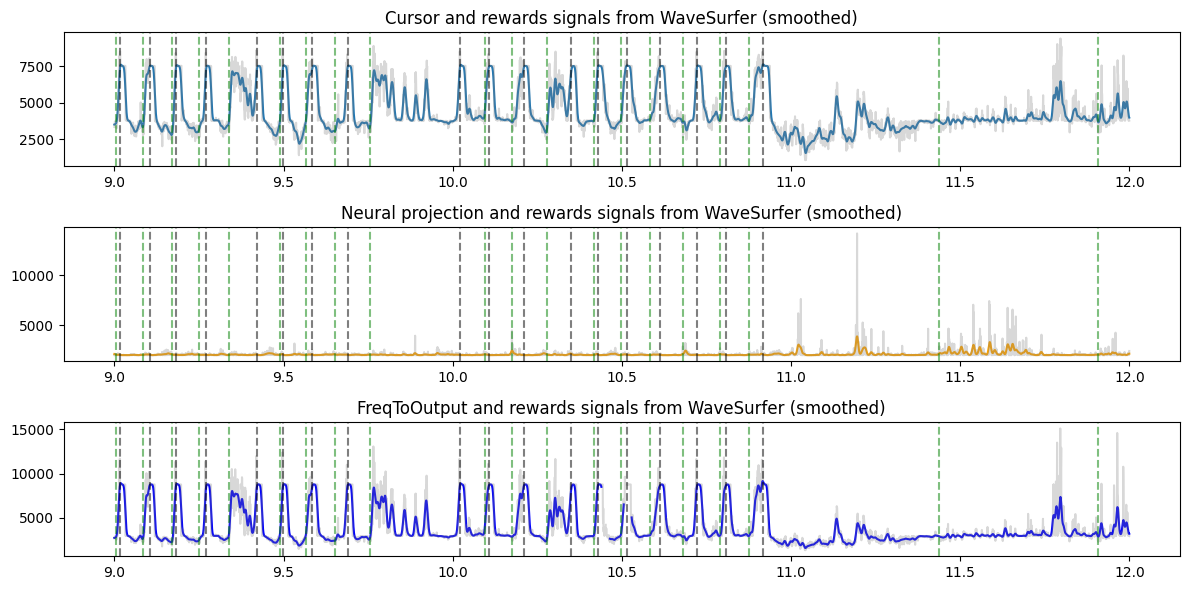

In [31]:

from scipy.ndimage import gaussian_filter1d
day_idx = first_remaping_day_idx
cursor = r["data_ws"][day_list[day_idx]]["cursor"].load()
time_set = np.arange(len(cursor)) / sampling_rate/ 60
active_reward_times = active_reward_times_min_list[day_idx]
neural_course_value = get_coursor_from_neural_data_decoder_formula(r, day_list[day_idx], p=2, sampling_rate=sampling_rate)
neural_course = get_audirory_tone_from_cursor(neural_course_value, f_min=2000, f_max=18000)
decoder_logger = r["extras"]["logger_dfs"][day_list[day_idx]]['decoder'].load()
freq_to_output = decoder_logger['freqToOutput'].to_numpy()
trials_start_frams = trials_start_frams_list[day_idx]

k_min = 3
k_samples = k_min * sampling_rate * 60  # 5 minutes worth of samples
start_time_min = 9 
start_time_samples = start_time_min * sampling_rate * 60  # 1 minute worth of samples
# Mild smoothing
# sigma is in samples. At 30 Hz, sigma=10 is ~670 ms.
cursor_smooth = gaussian_filter1d(cursor.astype(float), sigma=5)
neural_course_smooth = gaussian_filter1d(neural_course.astype(float), sigma=5)
freq_to_output_smooth = gaussian_filter1d(freq_to_output.astype(float), sigma=5)

fig, ax = plt.subplots(3, 1, figsize=(12, 6))
ax[0].plot(time_set[start_time_samples:start_time_samples+k_samples],
            cursor_smooth[start_time_samples:start_time_samples+k_samples], label="cursor")
ax[0].plot(time_set[start_time_samples:start_time_samples+k_samples],
            cursor[start_time_samples:start_time_samples+k_samples], label="cursor raw", alpha=0.3, color="gray")
ax[1].plot(time_set[start_time_samples:start_time_samples+k_samples],
            neural_course_smooth[start_time_samples:start_time_samples+k_samples], label="neural projection", color="orange")
ax[2].plot(time_set[start_time_samples:start_time_samples+k_samples],
            freq_to_output_smooth[start_time_samples:start_time_samples+k_samples], label="freqToOutput", color="blue")
ax[1].plot(time_set[start_time_samples:start_time_samples+k_samples], 
           neural_course[start_time_samples:start_time_samples+k_samples], label="neural projection raw", alpha=0.3, color="gray")
ax[2].plot(time_set[start_time_samples:start_time_samples+k_samples],
            freq_to_output[start_time_samples:start_time_samples+k_samples], label="freqToOutput raw", alpha=0.3, color="gray")
# add vertical lines for each active reward time
for reward_time in active_reward_times:
    if start_time_min <= reward_time <= (start_time_min+k_min):
        ax[0].axvline(x=reward_time, color='k', linestyle='--', alpha=0.5)
        ax[1].axvline(x=reward_time, color='k', linestyle='--', alpha=0.5)
        ax[2].axvline(x=reward_time, color='k', linestyle='--', alpha=0.5)
for t_start in trials_start_frams:
    trial_start_time_min = t_start / (sampling_rate * 60)
    if start_time_min <= trial_start_time_min <= (start_time_min+k_min):
        ax[0].axvline(x=trial_start_time_min, color='g', linestyle='--', alpha=0.5)
        ax[1].axvline(x=trial_start_time_min, color='g', linestyle='--', alpha=0.5)
        ax[2].axvline(x=trial_start_time_min, color='g', linestyle='--', alpha=0.5)
ax[0].set_title("Cursor and rewards signals from WaveSurfer (smoothed)")
ax[1].set_title("Neural projection and rewards signals from WaveSurfer (smoothed)")
ax[2].set_title("FreqToOutput and rewards signals from WaveSurfer (smoothed)")
plt.tight_layout()
output_path = os.path.join(output_dir, f"{mouse_name}_cursor_neural_projection_freqToOutput_day_{day_idx}.png")
plt.savefig(output_path, dpi=300)
plt.show()

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type numpy_array.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


Day 21 remapping start time: 10.92 min
Day 22 remapping start time: 10.94 min
Day 23 remapping start time: 10.85 min
Day 24 remapping start time: 11.03 min
Day 25 remapping start time: 10.95 min
Day 26 remapping start time: 11.02 min
Day 27 remapping start time: 10.67 min
Day 28 remapping start time: 10.82 min
Day 29 remapping start time: 11.10 min


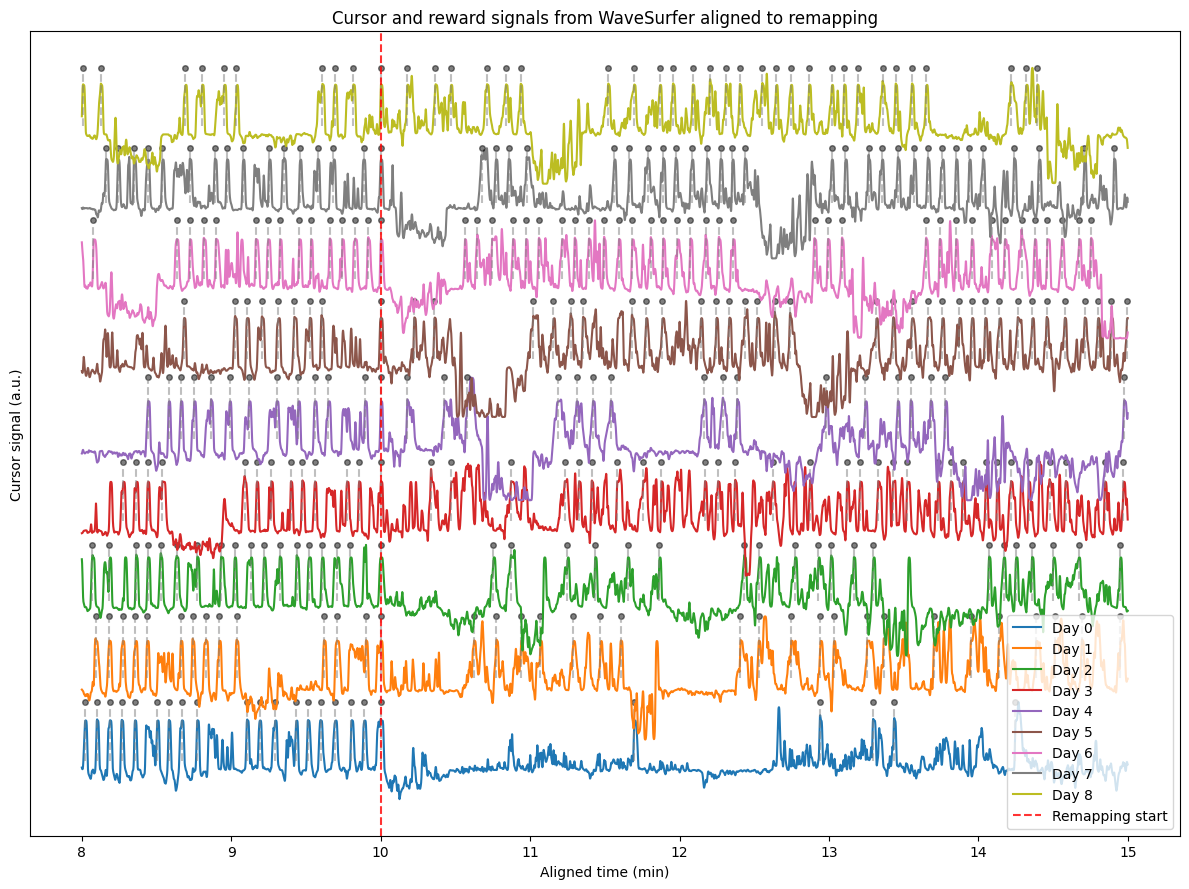

In [ ]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt

sigma_cursor = 5
k_day = 9

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

y_lap = 0
start_of_remaping_min = 10
duration_to_plot_min = 7
start_time_diff_min = 2

if first_remaping_day_idx is not None:
    for day_idx in range(first_remaping_day_idx, first_remaping_day_idx + k_day):

        cursor = r["data_ws"][day_list[day_idx]]["cursor"].load()
        cursor = np.asarray(cursor).squeeze()

        cursor_smooth = gaussian_filter1d(cursor.astype(float), sigma=sigma_cursor)

        time_of_remaping_frame = int(remapping_start_frame[day_idx])
        time_of_remaping_min = time_of_remaping_frame / sampling_rate / 60

        #print(f"Day {day_idx} remapping start time: {time_of_remaping_min:.2f} min")

        # aligned time axis:
        # remapping frame will always be at start_of_remaping_min
        time_set_aligned = (
            np.arange(len(cursor)) - time_of_remaping_frame
        ) / sampling_rate / 60 + start_of_remaping_min

        start_time_samples = int(time_of_remaping_frame - start_time_diff_min * sampling_rate * 60)
        end_time_samples = int(start_time_samples + duration_to_plot_min * sampling_rate * 60)

        start_time_samples = max(start_time_samples, 0)
        end_time_samples = min(end_time_samples, len(cursor_smooth))

        cursor_segment = cursor_smooth[start_time_samples:end_time_samples]
        time_segment = time_set_aligned[start_time_samples:end_time_samples]

        segment_max = np.nanmax(cursor_segment)

        ax.plot(
            time_segment,
            cursor_segment + y_lap,
            label=f"Day {day_idx - first_remaping_day_idx}",
        )

        active_reward_times_min = active_reward_times_min_list[day_idx]

        for reward_time_min in active_reward_times_min:
            reward_time_frame = int(reward_time_min * sampling_rate * 60)

            if start_time_samples <= reward_time_frame <= end_time_samples:
                reward_time_aligned = (
                    reward_time_frame - time_of_remaping_frame
                ) / sampling_rate / 60 + start_of_remaping_min

                ax.plot(
                    reward_time_aligned,
                    y_lap + segment_max,
                    "k.",
                    alpha=0.5,
                    markersize=8
                )

                ax.plot(
                    [reward_time_aligned, reward_time_aligned],
                    [
                        y_lap + segment_max / 2,
                        y_lap + segment_max,
                    ],
                    "--",
                    alpha=0.5,
                    color="gray",
                )

        y_lap += segment_max*2/3 + 100

    ax.axvline(
        start_of_remaping_min,
        color="red",
        linestyle="--",
        alpha=0.8,
        label="Remapping start",
    )

    ax.set_title("Cursor and reward signals from WaveSurfer aligned to remapping")
    ax.set_xlabel("Aligned time (min)")
    ax.set_ylabel("Cursor signal (a.u.)")
    ax.set_yticks([])
    ax.legend()
    plt.tight_layout()
    output_path = os.path.join(output_dir, f"{mouse_name}_cursor_aligned_to_remapping.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

In [21]:
r["extras"]["expParams"]["20230715"].keys()

['baselineStuff', 'directory', 'image_hash_function', 'loggerNames', 'params']

In [22]:
params = r["extras"]['expParams']['20230710']['params'].load()
params['trial']

{'LED_duration': array(0.2),
 'LED_ramp_duration': array(0.1),
 'duration_ITI': array(3.),
 'duration_buildingUpStats': array(1800.),
 'duration_quiescenceHold': array(3.),
 'duration_quiescence_hold': array(3.),
 'duration_rewardDelivery': array(1.),
 'duration_threshold': array(3.),
 'duration_timeout': array(4.),
 'duration_trial': array(20.),
 'reward_delay': array(0.),
 'reward_duration': array(52.)}

In [23]:
baselineStuff = r["extras"]["expParams"]["20230710"]["baselineStuff"].load()
baselineStuff.keys()

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type scipy_sparse_array.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


dict_keys(['Fs_frameRate', 'MC', 'ROIs', 'block_sequence', 'cellNumsToUse', 'cursors', 'directory', 'factor_space', 'factor_to_use', 'file_baseName', 'framesForMeanImForMC', 'frames_perFile', 'frames_totalExpected'])

In [24]:
expLoggers = r["extras"]["logger_dfs"][first_remaping_day]
expLoggers


Path: C:\Data\datasets\bmi_packets\bmi_packets\mouse_0403L.richfile\extras.dict_item\value.dict\logger_dfs.dict_item\value.dict\20230725.dict_item\value.dict (dict)
├── 'decoder':   (pandas_dataframe)
├── 'motionCorrection':   (pandas_dataframe)
├── 'timeSeries':   (pandas_dataframe)
├── 'timers':   (pandas_dataframe)
├── 'trials':   (pandas_dataframe)



RichFile(path=C:\Data\datasets\bmi_packets\bmi_packets\mouse_0403L.richfile\extras.dict_item\value.dict\logger_dfs.dict_item\value.dict\20230725.dict_item\value.dict, backend=auto->directory, check=True, params_load={}, params_save={})

In [25]:
decoder_logger = expLoggers['decoder'].load()
decoder_logger.head()

,Unnamed: 0,cursor_brain,cursor_brain_raw,cursor_output,freqToOutput,voltage_cursorCurrentPos,decoder_angles,avgVec_angle
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.000505,0.000505,0.000505,2963.489258,1.240330,0.132967,0.304889
2,2,-0.115867,-0.115867,-0.115867,2772.769287,1.164381,-0.668777,0.467158
3,3,-0.278525,-0.278525,-0.278525,2526.584717,1.058226,-0.844030,0.203474
4,4,-0.006050,-0.006050,-0.006050,2952.408447,1.236052,-0.222042,0.772220


In [26]:
timeSeries = expLoggers['timeSeries'].load()
timeSeries.columns

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type pandas_dataframe.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


Index(['Unnamed: 0', 'frameNum', 'CS_quiescence', 'ET_trialStart', 'CE_trial',
       'soundVolume', 'counter_trialIdx', 'CS_threshold', 'ET_rewardToneHold',
       'CE_rewardToneHold', 'counter_rewardToneHold', 'frequencyOverride',
       'ET_rewardDelivery', 'CE_rewardDelivery', 'counter_rewardDelivery',
       'ET_ITI_withZ', 'CE_ITI_withZ', 'counter_ITI_withZ',
       'ET_waitForBaseline', 'CE_waitForBaseline', 'ET_timeout', 'CE_timeout',
       'counter_timeout', 'CE_buildingUpStats', 'CE_experimentRunning',
       'NumOfRewardsAcquired', 'NumOfTimeouts', 'image_hash', 'trialNum',
       'trialNum*CE_trial', 'fakeFeedback_inUse', 'trialType_cursorOn',
       'trialType_feedbackLinked', 'trialType_rewardOn',
       'counter_last_z_correction', 'delta_moved', 'blockNum',
       'cursor_factor_to_use', 'cursor_angle_power', 'cursor_threshold_reward',
       'cursor_thresh_quiescence_cursorDecoder',
       'cursor_thresh_quiescence_cursorMag', 'cursor_win_smooth_cursor'],
      dtype=

In [27]:
timers = expLoggers['timers'].load()
timers

,Unnamed: 0,time_now,tic_toc
0,0,739092.516078,1.698845
1,1,739092.516078,0.016576
2,2,739092.516079,0.013235
3,3,739092.516079,0.013417
4,4,739092.516079,0.017369
...,...,...,...
143995,143995,NaN,NaN
143996,143996,NaN,NaN
143997,143997,NaN,NaN
143998,143998,NaN,NaN


In [28]:
trials = expLoggers['trials'].load()
trials

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type pandas_dataframe.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


,Unnamed: 0,trialNum_trialStart,time_now_trialStart,frameNum_trialStart,trialType_cursorOn,trialType_feedbackLinked,trialType_rewardOn,blockNum,factor_to_use,trialNum_trialEnd,time_now_trialEnd,frameNum_trialEnd,success_outcome
0,0,1.0,739092.516764,1828.0,1.0,1.0,1.0,1.0,2.0,1.0,739092.516781,1871.0,1.0
1,1,2.0,739092.516855,2064.0,1.0,1.0,1.0,1.0,2.0,2.0,739092.516946,2299.0,1.0
2,2,3.0,739092.517008,2460.0,1.0,0.0,1.0,1.0,2.0,3.0,739092.517239,3059.0,0.0
3,3,4.0,739092.517353,3353.0,1.0,1.0,1.0,1.0,2.0,4.0,739092.517405,3488.0,1.0
4,4,5.0,739092.517452,3610.0,0.0,1.0,0.0,1.0,2.0,5.0,739092.517683,4209.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
498,498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
